# Week 0, Tutorial 3: Basic Data Visualisation with matplotlib

**Author**: Sariana Ramoutar

This notebook focuses on basic data visualisation techniques using `matplotlib` to analyse emergency triage data. It covers cleaning the data, plotting distributions, identifying correlations, and highlighting clinical thresholds for vital signs.

### Connecting to Google Drive

This cell ensures that the notebook can access files stored in your Google Drive, which is where the dataset is located. It's a standard procedure in Colab to mount your Drive.

In [1]:
# Make the Google Drive data set accessible to Colab.
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully.")

Mounted at /content/drive
Drive mounted successfully.


### Importing Essential Libraries

Here, we import the Python libraries necessary for data manipulation and visualisation:

*   **`pandas` (as `pd`)**: This is the workhorse for data handling, perfect for tabular data like our dataset.
*   **`numpy` (as `np`)**: Provides powerful numerical operations, often used in conjunction with pandas.
*   **`matplotlib.pyplot` (as `plt`)**: The primary library for creating static, interactive, and animated visualisations in Python.

In [2]:
# Confirm the version of Python before coding anything else.
import sys
print(f"Current Python Version: {sys.version}")

Current Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [3]:
# Import the libraries. Pandas is the most used.

import pandas as pd     # Shortened for easy coding
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


### Loading the Dataset

This cell defines the file path to our emergency triage dataset, which is stored as a CSV file in Google Drive. It then uses `pandas` to read this CSV into a DataFrame called `df`. The `df.head(10)` command provides a quick peek at the first ten rows of the raw, 'unclean' data.

In [4]:
# Define the path to the dataset and load it into a pandas DataFrame (df)
dataset_path = '/content/drive/MyDrive/CariSurg Documents/EmergencyTriageDataset_Reduced_Dirty.csv'

df = pd.read_csv(dataset_path)

df.head(10) # Unclean preview

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,Male,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,Female,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,FEMALE,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,Male,15.0,100,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,Female,15.0,120,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,Male,15.0,100,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,Female,15.0,153,82.0,105.67,130.0,37.0,19.0,21.0


### Data Cleaning and Preprocessing

This section applies a series of cleaning steps to the raw data, addressing common issues found in real-world datasets. This includes:

*   **Standardising 'Gender' entries**: Converting various string formats (e.g., 'Male', 'MALE', '0', 'Female', 'FEMALE', '1') into a consistent numerical representation (1 for male, 0 for female).
*   **Handling invalid values and outliers**: For vital signs like GCS, SBP, DBP, Pulse, Temp, RR, and FiO2, values outside clinically sensible ranges are identified and replaced with `NaN` (Not a Number).
*   **Converting 'Temperature' to Celsius**: Ensures all temperature readings are in a uniform unit, handling both Celsius and Fahrenheit inputs.
*   **Imputing missing values**: Any `NaN` values resulting from cleaning or original data gaps are filled using the median of their respective columns. This helps maintain data integrity without introducing significant bias.
*   **Calculating Mean Arterial Pressure (MAP)**: If MAP is missing, it's calculated from SBP and DBP using a standard formula.

In [5]:
# Apply cleaning from Assignments 1 and 2.

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    """Converts temperature values to Celsius, handling 'C' and 'F' suffixes."""
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
display(df.head(10))

Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,1,15.0,100.0,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,0,15.0,120.0,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,1,15.0,100.0,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110.0,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,0,15.0,153.0,82.0,105.67,130.0,37.0,19.0,21.0


### Respiratory Rate (RR) Distribution

This code block generates a histogram to visualise the distribution of respiratory rates among patients. It includes:

*   **Binning**: The `RR` values are grouped into bins corresponding to each integer from 5 to 60.
*   **Clinical Thresholds**: Vertical lines and shaded regions highlight key clinical thresholds for `RR`:
    *   **Bradypnea (slow breathing)**: Below 12 breaths per minute (red).
    *   **Normal**: Between 12 and 20 breaths per minute (green).
    *   **Tachypnea (fast breathing)**: Above 20 breaths per minute (orange).

This plot helps to quickly identify the proportion of patients presenting with abnormal respiratory rates, providing insight into potential respiratory distress.

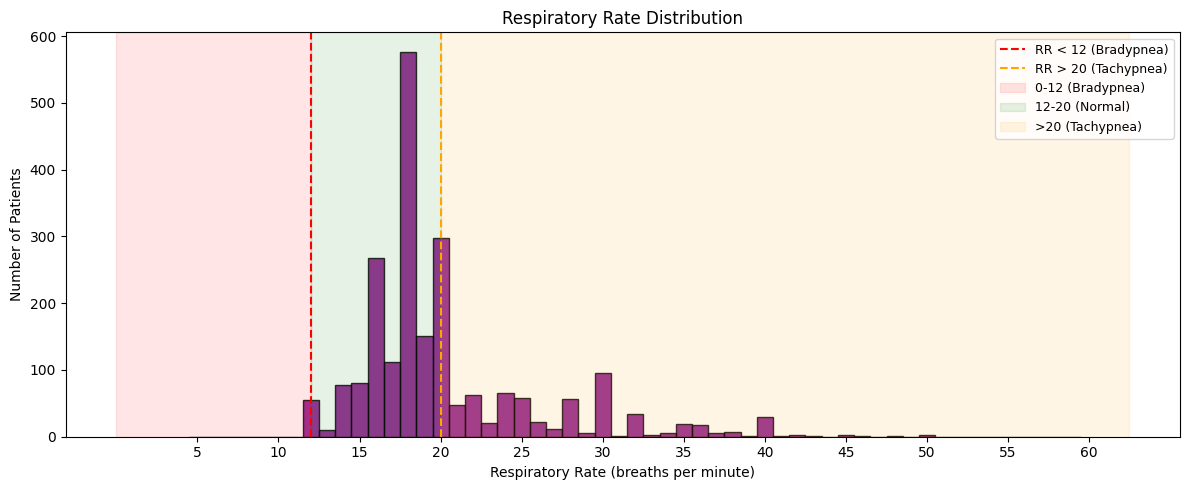

Saved: rr_histogram.png


In [6]:
# Histogram: Respiratory Rate (RR) distribution
fig, ax = plt.subplots(figsize=(12, 5))

# RR values are typically between 5 and 60, so using a bin for each integer value in this range.
ax.hist(df['RR'], bins=range(5, 61), edgecolor='black',
        color='purple', alpha=0.8, align='left')

# Add vertical lines for clinical thresholds for Respiratory Rate
# Normal adult resting respiratory rate is typically 12 to 20 breaths per minute.
ax.axvline(x=12, color='red', linestyle='--', linewidth=1.5,
           label='RR < 12 (Bradypnea)')  # legend
ax.axvline(x=20, color='orange', linestyle='--', linewidth=1.5,
           label='RR > 20 (Tachypnea)')  # legend

# Add shaded regions for clinical thresholds
# 0-12 bpm: light red (Bradypnea)
ax.axvspan(0, 12, color='red', alpha=0.1, label='0-12 (Bradypnea)')
# 12-20 bpm: light green (Normal)
ax.axvspan(12, 20, color='green', alpha=0.1, label='12-20 (Normal)')
# >20 bpm: orange (Tachypnea)
ax.axvspan(20, ax.get_xlim()[1], color='orange', alpha=0.1, label='>20 (Tachypnea)')

ax.set_title('Respiratory Rate Distribution', fontsize=12)  # title of histogram
ax.set_xlabel('Respiratory Rate (breaths per minute)')  # x axis
ax.set_ylabel('Number of Patients') # y axis
ax.set_xticks(range(5, 61, 5))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rr_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: rr_histogram.png")

# Research Question: What proportion of Emergency Department patients present with abnormal respiratory rates (bradypnea or tachypnea) compared to the
# normal clinical baseline of 12–20 breaths per minute?
# Justification for this plot: Shows what proportion of patients at the ED are exhibiting signs of respiratory distress. The normal baseline is between
# 12 and 20 breaths per minute. Anyone to the left of the first line (threshold) is in danger (bradypnea); anyone to the right of the second line is
# fighting for air (tachypnea).

### Pulse Rate vs. Respiratory Rate: Identifying Cardiorespiratory Distress

This scatter plot visualises the relationship between a patient's pulse rate and respiratory rate. It's designed to identify patients potentially experiencing combined cardiac and respiratory distress, which can be an indicator of 'shock'.

*   **Scatter Points**: Each point represents a patient, with their pulse rate on the x-axis and respiratory rate on the y-axis.
*   **Clinical Thresholds**: Horizontal and vertical lines mark critical thresholds:
    *   `RR > 20 bpm` (Tachypnea - red horizontal line).
    *   `RR < 12 bpm` (Bradypnea - green horizontal line).
    *   `Pulse > 100 bpm` (Tachycardia - blue vertical line).
*   **Highlighted Zones**:
    *   The **upper-right quadrant (red)** indicates patients with both tachycardia and tachypnea, suggesting severe physiological distress.
    *   The **lower-left quadrant (green)** represents patients within more normal ranges for both vital signs.

This visualisation is crucial for spotting patients who might need immediate attention due to combined cardiorespiratory issues.

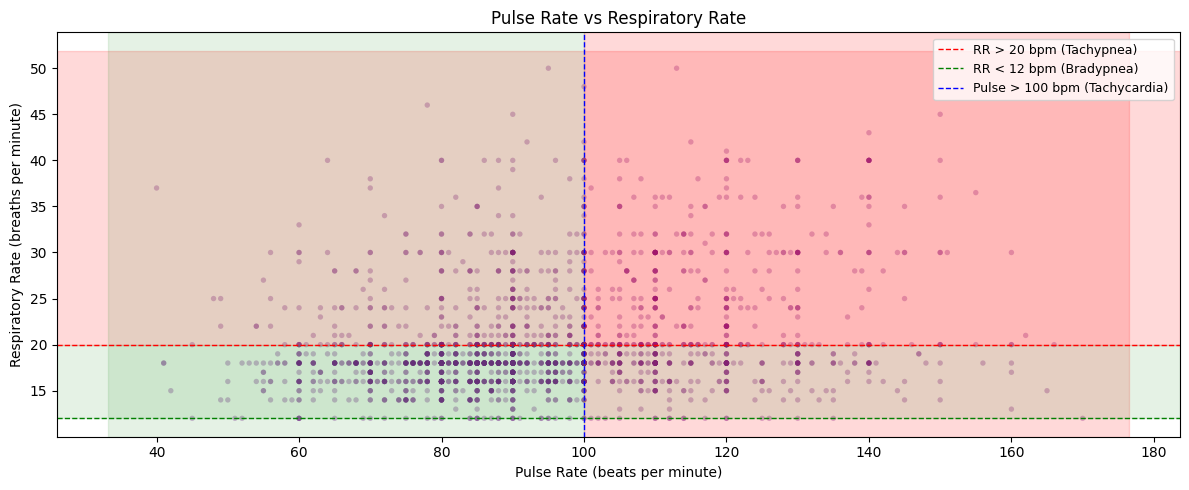

Saved: pulse_vs_rr_scatter.png


In [7]:
# Scatter plot: Pulse vs RR — identifying high-risk 'shock' patients
fig, ax = plt.subplots(figsize=(12, 5))

# Plot the scatter points: 'Pulse' on the x-axis, 'RR' on the y-axis
ax.scatter(df['pulse'], df['RR'],
           alpha=0.3, s=15, color='#7E1E96', edgecolors='none')

ax.set_title('Pulse Rate vs Respiratory Rate', fontsize=12) # title of scatter plot
ax.set_xlabel('Pulse Rate (beats per minute)')  # x axis
ax.set_ylabel('Respiratory Rate (breaths per minute)')  # y axis

# The upper normal limit of RR is 20 breaths/min.
# RR is on the y axis so this is a horizontal line.
ax.axhline(y=20, color='red', linestyle='--', linewidth=1, label='RR > 20 bpm (Tachypnea)')
ax.axhline(y=12, color='green', linestyle='--', linewidth=1, label='RR < 12 bpm (Bradypnea)')

# The threshold for tchycardia (high pulse) is 100 beats/min.
# Pulse is on the x axis so this is a vertical line.
ax.axvline(x=100, color='blue', linestyle='--', linewidth=1, label='Pulse > 100 bpm (Tachycardia)')

# Highlight the critical upper-right quadrant (Pulse > 100 and RR > 20).
ax.axvspan(xmin=100, xmax=ax.get_xlim()[1], color='red', alpha=0.15)
ax.axhspan(ymin=20, ymax=ax.get_ylim()[1], color='red', alpha=0.15)

# Highlight the normal lower-left quadrant (Pulse < 100 and 12 <= RR <= 20).
ax.axvspan(xmin=ax.get_xlim()[0], xmax=100, color='green', alpha=0.1)
ax.axhspan(ymin=12, ymax=20, color='green', alpha=0.1)

ax.legend(fontsize=9)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
# Save the plot to a file
plt.savefig('pulse_vs_rr_scatter.png', dpi=100, bbox_inches='tight')
# Display the plot
plt.show()
print("Saved: pulse_vs_rr_scatter.png")

# Research Question: How prevalent is concurrent cardiorespiratory distress among incoming emergency patients?
# Justification for this plot: This scatter plot helps identify patients who are simultaneously experiencing elevated pulse rates (tachycardia)
# and elevated respiratory rates (tachypnea). The upper-right quadrant formed by the intersection of the two reference lines (Pulse > 100 bpm and
# RR > 20 breaths/min) highlights patients who may be in a state of shock or severe physiological distress, requiring immediate attention in an
# emergency setting. This combination of vital signs is a key indicator of patient severity.

### Shock Index: Detecting Occult Shock

This scatter plot introduces and visualises the 'Shock Index', a critical metric used to identify patients who might be in 'occult shock'—a dangerous state where vital signs appear deceptively normal.

*   **Shock Index Calculation**: The `Shock_Index` is calculated by dividing `Pulse` by `SBP` (Systolic Blood Pressure).
*   **Plotting**: All patients are plotted with `SBP` on the x-axis and `Pulse` on the y-axis. Patients with a critical Shock Index (`>= 1.0`) are highlighted in orange.
*   **Clinical Ranges**:
    *   **Normal Range (Green Rectangle)**: SBP between 90-140 mmHg and Pulse between 60-100 bpm (Shock Index 0.5-0.7).
    *   **Danger Zone (Red Rectangle)**: Patients with a Pulse > 100 bpm and SBP < 90 mmHg, indicating hypotension and tachycardia, a sign of severe circulatory collapse.

The Shock Index is a more sensitive indicator than individual vital signs for detecting early stages of shock, especially when the body is compensating for blood loss or other severe conditions.

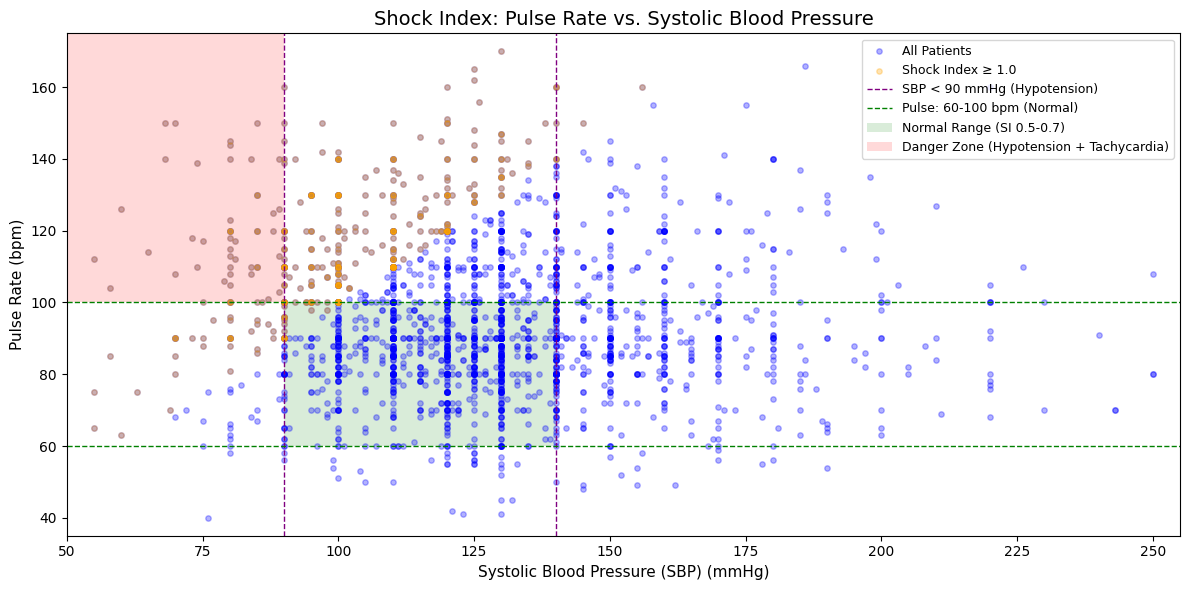

Saved: shock_index_scatter.png


In [8]:
import matplotlib.patches as patches

# Scatter plot: Shock Index (Pulse vs. SBP) — identifying occult shock.
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate Shock Index: Pulse divided by SBP
df['Shock_Index'] = df['pulse'] / df['SBP']

# Filter for points where Shock Index >= 1.0
critical_si_patients = df[df['Shock_Index'] >= 1.0]

# Plot all patients (main scatter plot)
ax.scatter(df['SBP'], df['pulse'], alpha=0.3, s=15, color='blue', label='All Patients')

# Plot patients with critical Shock Index on top, in a distinct color and marker.
ax.scatter(critical_si_patients['SBP'], critical_si_patients['pulse'],
           color='orange', s=15, alpha=0.3, marker='o', label='Shock Index \u2265 1.0')

ax.set_title('Shock Index: Pulse Rate vs. Systolic Blood Pressure', fontsize=14)
ax.set_xlabel('Systolic Blood Pressure (SBP) (mmHg)', fontsize=11)
ax.set_ylabel('Pulse Rate (bpm)', fontsize=11)

# Dynamically set axis limits to include all points with a small buffer
ax.set_xlim(df['SBP'].min() - 5, df['SBP'].max() + 5)
ax.set_ylim(df['pulse'].min() - 5, df['pulse'].max() + 5)

# Add clinical threshold lines
# SBP thresholds
ax.axvline(x=90, color='purple', linestyle='--', linewidth=1, label='SBP < 90 mmHg (Hypotension)')
ax.axvline(x=140, color='purple', linestyle='--', linewidth=1)
# Pulse thresholds
ax.axhline(y=60, color='green', linestyle='--', linewidth=1, label='Pulse: 60-100 bpm (Normal)')
ax.axhline(y=100, color='green', linestyle='--', linewidth=1)

# Highlight the clinically acceptable range (Green Zone) using Rectangle patch.
# SBP between 90-140 mmHg and Pulse between 60-100 bpm
rect_green = patches.Rectangle((90, 60), 140 - 90, 100 - 60, linewidth=0, facecolor='green', alpha=0.15, zorder=0, label='Normal Range (SI 0.5-0.7)')
ax.add_patch(rect_green)

# Highlight the Danger Zone (Upper-Left Quadrant) using Rectangle patch.
# Pulse > 100 bpm and SBP < 90 mmHg
# The width of the rectangle is 90 - ax.get_xlim()[0]
# The height of the rectangle is ax.get_ylim()[1] - 100
rect_red = patches.Rectangle((ax.get_xlim()[0], 100), 90 - ax.get_xlim()[0], ax.get_ylim()[1] - 100, linewidth=0, facecolor='red', alpha=0.15, zorder=0, label='Danger Zone (Hypotension + Tachycardia)')
ax.add_patch(rect_red)

ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('shock_index_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: shock_index_scatter.png")

# Research Question: How many patients have a dangerous Shock Index, and does this score help us catch hidden shock in patients who otherwise look normal?
# Justification for the plot: The Shock Index can determine if a patient is in "occult shock," a state where they are dangerously ill but their individual
# vital signs still appear deceptively normal. A normal Shock Index falls between 0.5 to 0.7. Elevated is 0.8 to 0.9, and critical is >= 1.0. In severe medical
# emergencies like hemorrhage, sepsis or massive trauma, the body enters a compensatory phase. To stay alive, the heart rate climbs rapidly to compensate for
# dropping blood volume, which temporarily keeps the SBP within normal range. SBP is supposed to be higher than pulse (inverse relationship), but if they are
# equal, it indicates significant circulatory collapse.

### Box Plots for All Numeric Vitals: An Overview

This section generates a series of box plots, one for each major numeric vital sign (`SBP`, `DBP`, `MAP`, `pulse`, `Temp`, `RR`, `GCS`, `Fio2`). This provides a quick, side-by-side overview of the distribution, central tendency, and spread of each vital sign after the cleaning process.

*   **Visualisation**: Each box plot shows the median, interquartile range (IQR), and potential outliers for a given vital sign.
*   **Insights**: These plots are useful for:
    *   Understanding the typical range of values.
    *   Identifying any remaining extreme outliers.
    *   Comparing the distributions across different vital signs at a glance.

This comprehensive view helps in assessing the overall health of the dataset and the patient population.

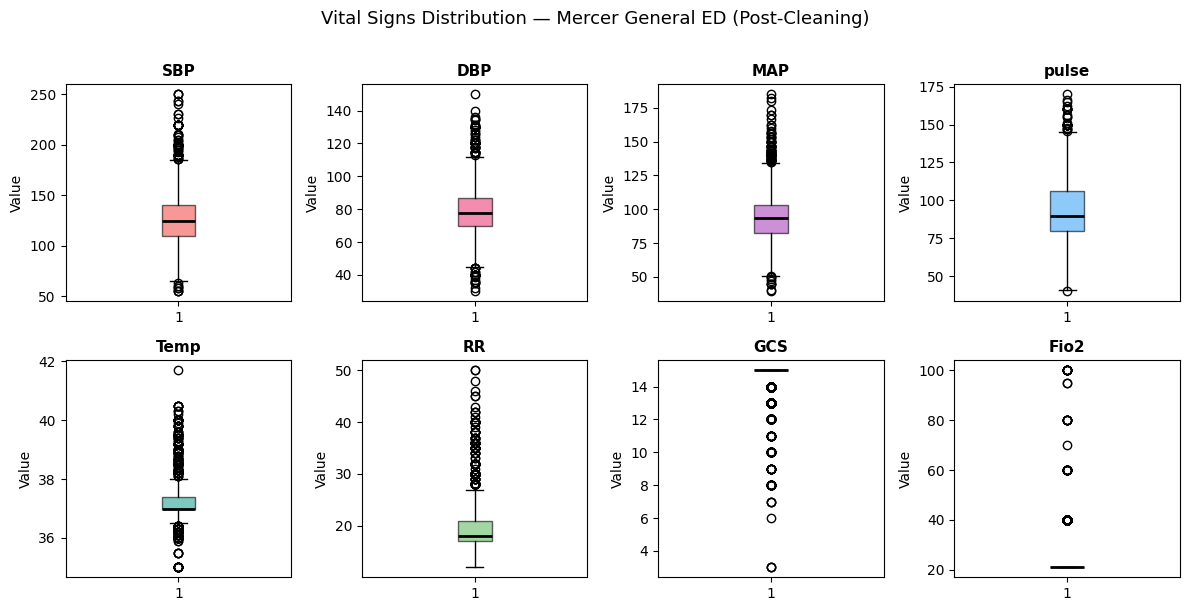

Saved: vitals_boxplots.png


In [9]:
# Box plots for all numeric vitals — side by side for a quick overview (from Tutorial)
vitals = ['SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'GCS', 'Fio2']

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

colors = ['#EF5350','#EC407A','#AB47BC','#42A5F5','#26A69A','#66BB6A','#FFA726','#8D6E63']

for i, (vital, col) in enumerate(zip(vitals, colors)):
    axes[i].boxplot(df[vital].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=col, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(vital, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Vital Signs Distribution — Mercer General ED (Post-Cleaning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vitals_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: vitals_boxplots.png")

### Saving and Summarising Plots

This final cell is a practical step, ensuring that all the visualisations generated in this notebook are saved as PNG image files. It then lists all the saved plot files along with their sizes.

*   **File Naming**: Plots are saved with descriptive names (e.g., `rr_histogram.png`).
*   **Image Quality**: The `dpi` (dots per inch) setting is adjusted based on the intended use (e.g., `dpi=100` for smaller files suitable for platforms like Discord, and `dpi=150` for higher quality images for platforms like GitHub READMEs).

This ensures that the visual analysis can be easily shared and reviewed.

In [10]:
# Always save plots before posting to Discord or GitHub
# Use dpi=100 for Discord (smaller file), dpi=150 for GitHub README

# Summary: all the plots we created today
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  pulse_vs_rr_scatter.png             (111 KB)
  rr_histogram.png                    (42 KB)
  shock_index_scatter.png             (123 KB)
  vitals_boxplots.png                 (62 KB)
